# Proyecto final — De la neurona a la figura
### Área: LP (núcleo lateral posterior del tálamo) · Comparación asignada: rejillas estáticas vs. rejillas en movimiento
**Integrantes:** Leidy Ruiz · Valentina Salamanca

**Datos:** Allen Brain Observatory, Visual Coding Neuropixels — Siegle JH et al. (2021).
*Survey of spiking in the mouse visual system reveals functional hierarchy.* Nature 592, 86–92.

**Declaración de uso de IA (sección 9 del enunciado):** este notebook fue construido con la asistencia de un
modelo de lenguaje (Claude) para escribir y depurar el código, siguiendo el pipeline propuesto en el enunciado
del proyecto. Los errores más comunes que el modelo cometió al generar código —y que tuvimos que corregir
explícitamente— fueron:
- Un primer intento de bootstrap que no remuestreaba a nivel de ratón (solo neuronas), lo cual da un
  intervalo de confianza falsamente angosto. Se corrigió forzando el sorteo con reemplazo en los tres
  niveles: ratón → neurona → ensayo.
- Cálculos que mezclaban ensayos de un ratón con neuronas de otro (al no filtrar `e_raton` == `u_raton`
  antes de promediar), lo que habría inflado artificialmente las tasas de disparo.
- Una versión inicial del PSTH poblacional que filtraba la tabla completa de espigas (más de 10 millones de
  filas) dentro de un doble ciclo por neurona, lo que la hacía impráctica de ejecutar; se optimizó agrupando
  las espigas por neurona una sola vez antes de los cálculos.

Todas estas correcciones están incorporadas en el código de este notebook.


## 1. Descarga y carga de datos

Cada área del sorteo tiene su propio archivo `.npz` en Drive (sección 4 del enunciado). Lo descargamos con
`gdown` y lo cargamos con `allow_pickle=True`, porque algunas columnas (`u_onda`, `e_imagen`) no son arreglos
numéricos simples sino objetos de Python.

In [1]:
# --- Instalar gdown (silencioso) y cargar numpy ---
!pip install gdown -q
import numpy as np
import gdown

# ---- Identificadores de Drive para cada área del sorteo (sección 4 del enunciado) ----
IDS = {
    "VISp":  "17-YMZMNfKXKYUK-vtPEPETfpUP0iHHut",   # 382 neuronas
    "VISl":  "1GqceDf_3YPgPWAbDsIrjQySj4DRsd8Tw",   # 277 neuronas
    "VISal": "1TTyTRj92kbf7H6KE5-ah0DT7Ho2pV1pC",   # 481 neuronas
    "VISrl": "1n5XdMa5ZvRcKu7eTuI8latBQt5EHkLjJ",   # 308 neuronas
    "VISam": "1ODzh0cs3p_YE1FYwvET1qeRNxU1hqFbO",   # 368 neuronas
    "VISpm": "1kL7fnRaB5tYVrNoabMGTqJzHnz8GWl_z",   # 296 neuronas
    "LGd":   "1ClWjSlBLWNbpVKKF3Kf5QpOwTtE0Wa2_",   # 301 neuronas
    "LP":    "1P7GMFi7u4cy_3AApazkyuovTKf4IFou0",   # 431 neuronas  <-- la nuestra
}

MI_AREA = "LP"  # área asignada por sorteo a esta pareja

# --- Descargar y cargar el archivo ---
gdown.download(id=IDS[MI_AREA], output="datos.npz", quiet=False)

# allow_pickle=True porque u_onda (forma de onda) y e_imagen (índice de imagen)
# son columnas de objetos de Python, no arreglos numéricos simples.
datos = np.load("datos.npz", allow_pickle=True)

print(f"\nÁrea: {MI_AREA}  ·  variables del archivo ({len(datos.files)}):")
print(datos.files)


Downloading...
From (original): https://drive.google.com/uc?id=1P7GMFi7u4cy_3AApazkyuovTKf4IFou0
From (redirected): https://drive.google.com/uc?id=1P7GMFi7u4cy_3AApazkyuovTKf4IFou0&confirm=t&uuid=f8b22187-8abd-4d1a-b59b-5c03a549536b
To: /content/datos.npz
100%|██████████| 42.1M/42.1M [00:00<00:00, 160MB/s]


Área: LP  ·  variables del archivo (26):
['area', 'fuente', 'filtro', 'u_id', 'u_raton', 'u_canal', 'u_profundidad', 'u_snr', 'u_amplitude_cutoff', 'u_presence_ratio', 'u_isi_violations', 'u_firing_rate', 'u_onda', 'e_clase', 'e_raton', 'e_t0', 'e_dur', 'e_orientacion', 'e_frec_temporal', 'e_frec_espacial', 'e_contraste', 'e_color', 'e_imagen', 's_unidad', 's_ensayo', 's_t']


## 2. Chequeos iniciales

Antes de construir las tablas, confirmamos que el archivo tiene la forma esperada: cuántas neuronas, cuántos
ratones (deben ser exactamente 5, según la sección 4 del enunciado), cuántos ensayos por clase de estímulo y
cuántos potenciales de acción en total.

In [2]:
# --- 1) Total de neuronas: identificadores únicos en u_id ---
n_neuronas = len(np.unique(datos["u_id"]))
print(f"Total de neuronas: {n_neuronas}")

# --- 2) Ratones distintos: valores únicos de u_raton (deben ser 5) ---
ratones_unicos = np.unique(datos["u_raton"])
print(f"Ratones distintos: {len(ratones_unicos)} -> {ratones_unicos}")
assert len(ratones_unicos) == 5, "Se esperaban exactamente 5 ratones (sección 4 del enunciado)."

# --- 3) Ensayos por clase de estímulo ---
clases, conteos = np.unique(datos["e_clase"], return_counts=True)
print("\nEnsayos por clase de estímulo:")
for clase, conteo in zip(clases, conteos):
    print(f"  {clase:>20s}: {conteo}")

# --- 4) Total de potenciales de acción (PAs) ---
n_pas = len(datos["s_t"])
print(f"\nTotal de potenciales de acción: {n_pas:,}")


Total de neuronas: 431
Ratones distintos: 5 -> [715093703 750749662 756029989 761418226 798911424]

Ensayos por clase de estímulo:
     drifting_gratings: 2000
               flashes: 750
     natural_movie_one: 40
        natural_scenes: 2000
           spontaneous: 750
       static_gratings: 1250

Total de potenciales de acción: 10,883,240


## 3. Construcción de las tres tablas (sección 3 del enunciado)

El archivo trae tres bloques de variables, identificados por su prefijo:
- `u_` → una fila por **neurona** (id, ratón, canal, calidad, forma de onda, ...)
- `e_` → una fila por **ensayo** (clase de estímulo, ratón, orientación, duración, ...)
- `s_` → una fila por **espiga** (unidad, ensayo, tiempo)

Las convertimos a tres `DataFrame` de pandas, indexados por posición (0, 1, 2, ...), que es como se referencian
entre sí (`s_unidad` apunta al índice de `neurona`; `s_ensayo` y `e_raton`/`u_raton` permiten emparejar).

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

campos_u = [k for k in datos.files if k.startswith('u_')]
campos_e = [k for k in datos.files if k.startswith('e_')]
campos_s = ['s_unidad', 's_ensayo', 's_t']

def _armar_tabla(campos, nombre_indice):
    """Arma un DataFrame a partir de los campos de un prefijo dado.
    Las columnas multidimensionales (como u_onda, que trae 7 canales x N muestras
    por neurona) se guardan como una lista de arreglos, una entrada por fila."""
    cols = {}
    for c in campos:
        arr = datos[c]
        cols[c] = list(arr) if arr.ndim > 1 else arr
    df = pd.DataFrame(cols)
    df.index.name = nombre_indice
    return df

neurona = _armar_tabla(campos_u, 'neurona')
ensayos = _armar_tabla(campos_e, 'ensayo')
spikes  = pd.DataFrame({c: datos[c] for c in campos_s})

n_neuronas = len(neurona)

print(f"neurona: {neurona.shape[0]:,} filas x {neurona.shape[1]} columnas")
print(f"ensayos: {ensayos.shape[0]:,} filas x {ensayos.shape[1]} columnas")
print(f"spikes:  {spikes.shape[0]:,} filas x {spikes.shape[1]} columnas")
print("\nColumnas de 'neurona':", list(neurona.columns))
print("Columnas de 'ensayos':", list(ensayos.columns))

# --- Chequeo de integridad: no debe haber neuronas duplicadas ---
assert neurona.index.is_unique, "El índice de 'neurona' tiene duplicados: revisar construcción de tablas."
assert (neurona.columns.value_counts() == 1).all(), "Hay columnas duplicadas en 'neurona'."


neurona: 431 filas x 10 columnas
ensayos: 6,790 filas x 10 columnas
spikes:  10,883,240 filas x 3 columnas

Columnas de 'neurona': ['u_id', 'u_raton', 'u_canal', 'u_profundidad', 'u_snr', 'u_amplitude_cutoff', 'u_presence_ratio', 'u_isi_violations', 'u_firing_rate', 'u_onda']
Columnas de 'ensayos': ['e_clase', 'e_raton', 'e_t0', 'e_dur', 'e_orientacion', 'e_frec_temporal', 'e_frec_espacial', 'e_contraste', 'e_color', 'e_imagen']


## 4. Índices de ensayos por clase de estímulo

Guardamos, para cada clase de estímulo que vamos a usar, los índices de fila en `ensayos` que le corresponden.
Esto se usa una y otra vez en el resto del notebook para filtrar `spikes` y `ensayos` sin repetir la condición
cada vez.

In [4]:
idx_drifting    = np.where(ensayos['e_clase'] == 'drifting_gratings')[0]
idx_static      = np.where(ensayos['e_clase'] == 'static_gratings')[0]
idx_spontaneous = np.where(ensayos['e_clase'] == 'spontaneous')[0]

# Duración nominal de cada clase (para las ventanas de conteo más abajo)
DUR_DRIFT  = 2.0    # s — rejillas en movimiento
DUR_STATIC = 0.25   # s — rejillas estáticas

print(f"Ensayos de drifting_gratings: {len(idx_drifting)}")
print(f"Ensayos de static_gratings:   {len(idx_static)}")
print(f"Ensayos de spontaneous:       {len(idx_spontaneous)}")


Ensayos de drifting_gratings: 2000
Ensayos de static_gratings:   1250
Ensayos de spontaneous:       750


## 5. Función `calcular_tasas` — Paso 3 del pipeline ("Contar")

Dado un conjunto de ensayos y una ventana de tiempo, devuelve una matriz **neurona × ensayo** con la tasa de
disparo (Hz) de cada neurona en cada ensayo.

⚠️ **Advertencia del enunciado (sección 3):** *"La columna ratón aparece en las neuronas y en los ensayos. No
la ignoren."* Cada neurona solo vio los ensayos de **su propio ratón** — nunca los de los otros 4. Por eso la
función deja en `NaN` cualquier combinación neurona-ensayo que no corresponda al mismo animal, en vez de
promediar por accidente sobre ensayos que esa neurona nunca vio.

In [5]:
def calcular_tasas(idx_ensayos, ventana):
    """Matriz neurona x ensayo con la tasa de disparo (Hz) en la ventana [0, ventana) s
    desde el inicio de cada ensayo.

    Queda en NaN donde el ensayo no pertenece al ratón de esa neurona, para no mezclar
    animales distintos (ver advertencia de la sección 3 del enunciado).
    """
    m = (spikes['s_ensayo'].isin(idx_ensayos)
         & (spikes['s_t'] >= 0)
         & (spikes['s_t'] < ventana))
    conteo = spikes.loc[m].groupby(['s_unidad', 's_ensayo']).size()

    matriz = conteo.unstack(fill_value=0)
    matriz = matriz.reindex(index=neurona.index, columns=idx_ensayos, fill_value=0)
    tasa = matriz / ventana

    raton_ensayo  = ensayos.loc[idx_ensayos, 'e_raton']
    raton_neurona = neurona['u_raton']
    # Máscara True donde el ratón de la neurona coincide con el ratón del ensayo
    mascara = raton_neurona.values[:, None] == raton_ensayo.values[None, :]
    return tasa.where(mascara)  # NaN donde NO coinciden


# --- Tasas evocada y basal para rejillas en movimiento ---
tasa_evocada = calcular_tasas(idx_drifting, ventana=DUR_DRIFT)
tasa_basal   = calcular_tasas(idx_spontaneous, ventana=DUR_DRIFT)

print(f"Tasa evocada mediana (movimiento): {np.nanmedian(tasa_evocada.values):.2f} Hz")
print(f"Tasa basal mediana (espontáneo):   {np.nanmedian(tasa_basal.values):.2f} Hz")


Tasa evocada mediana (movimiento): 5.00 Hz
Tasa basal mediana (espontáneo):   5.50 Hz


## 6. Z-score para rejillas en movimiento — Paso 4 del pipeline ("Decidir")

⚠️ **Advertencia del enunciado (sección 5, "IMPORTANTE"):** el Z-score de las rejillas en movimiento debe
usar la **combinación de características preferida de cada neurona** (dirección, frecuencia temporal y
frecuencia espacial) — no un promedio de todas las condiciones. Cada neurona puede preferir una combinación
distinta; primero encontramos cuál es su favorita, y el Z-score se calcula solo con esos ensayos.

El resultado se guarda directamente en `neurona['z_drift']` (con este nombre desde el principio, para no
depender de renombrar columnas más adelante).

In [6]:
carac = ensayos.loc[idx_drifting, ['e_raton', 'e_orientacion', 'e_frec_temporal', 'e_frec_espacial']].copy()
carac['combo'] = list(zip(carac['e_orientacion'], carac['e_frec_temporal'], carac['e_frec_espacial']))

z_drift = np.full(n_neuronas, np.nan)

for n in range(n_neuronas):
    fila = tasa_evocada.loc[n].dropna()          # solo ensayos de su propio ratón
    if len(fila) == 0:
        continue

    combos = carac.loc[fila.index, 'combo']
    promedio_por_combo = fila.groupby(combos).mean()
    combo_preferido = promedio_por_combo.idxmax()          # combinación que más la activa

    ensayos_pref = combos[combos == combo_preferido].index
    tasa_pref = fila.loc[ensayos_pref]

    basal = tasa_basal.loc[n].dropna()
    mu_basal, sd_basal = basal.mean(), basal.std()
    if sd_basal == 0 or np.isnan(sd_basal):
        continue  # neurona sin variabilidad basal: no se puede calcular un Z-score válido

    z_drift[n] = (tasa_pref.mean() - mu_basal) / sd_basal

neurona['z_drift'] = z_drift

print(f"Z (movimiento): mediana = {np.nanmedian(z_drift):.2f}, "
      f"máximo = {np.nanmax(z_drift):.2f}")


Z (movimiento): mediana = 0.95, máximo = 21.00


## 7. Z-score para rejillas estáticas — la misma lógica, con sus propias características

Las rejillas estáticas duran solo 250 ms y varían en orientación y frecuencia espacial (no tienen dirección
ni frecuencia temporal, porque no se mueven). Repetimos el mismo procedimiento del Paso 4, pero con la ventana
y las características propias de esta clase.

⚠️ **Advertencia del enunciado (sección 2):** los ensayos de "barrido en blanco" (blank sweep) tienen
parámetros vacíos (`NaN`). Los descartamos explícitamente antes de agrupar por combinación preferida, para que
no ensucien el `groupby`.

In [7]:
carac_static = ensayos.loc[idx_static, ['e_raton', 'e_orientacion', 'e_frec_espacial']].copy()
carac_static['combo'] = list(zip(carac_static['e_orientacion'], carac_static['e_frec_espacial']))

tasa_evocada_static = calcular_tasas(idx_static, ventana=DUR_STATIC)

z_static = np.full(n_neuronas, np.nan)

for n in range(n_neuronas):
    fila = tasa_evocada_static.loc[n].dropna()
    if len(fila) == 0:
        continue

    combos = carac_static.loc[fila.index, 'combo']
    # Descartar ensayos con parámetros vacíos (barridos en blanco, NaN)
    validos = combos.apply(lambda c: not any(pd.isna(x) for x in c))
    fila, combos = fila[validos], combos[validos]
    if len(fila) == 0:
        continue

    promedio_por_combo = fila.groupby(combos).mean()
    combo_preferido = promedio_por_combo.idxmax()
    tasa_pref = fila.loc[combos[combos == combo_preferido].index]

    basal = tasa_basal.loc[n].dropna()
    mu_basal, sd_basal = basal.mean(), basal.std()
    if sd_basal == 0 or np.isnan(sd_basal):
        continue

    z_static[n] = (tasa_pref.mean() - mu_basal) / sd_basal

neurona['z_static'] = z_static

print(f"Z (estáticas): mediana = {np.nanmedian(z_static):.2f}, "
      f"máximo = {np.nanmax(z_static):.2f}")

# --- Chequeo de integridad: ninguna columna debe haber quedado duplicada ---
assert (neurona.columns.value_counts() == 1).all(), "Columnas duplicadas en 'neurona' tras calcular z_static."


Z (estáticas): mediana = 1.73, máximo = 19.49


## 8. Validación visual del umbral — sección 9, regla 3 del enunciado

Antes de fijar qué Z-score cuenta como "responde", el enunciado pide mirar rasters de neuronas cerca del
corte: *"si en el raster se ve que la neurona responde pero tiene un Z-score que no pasa su umbral, quizás sea
bueno bajar el umbral"*.

Tomamos 6 neuronas con Z de movimiento entre 1.5 y 3.5 (alrededor de un candidato de umbral = 2.5) y miramos
sus rasters.

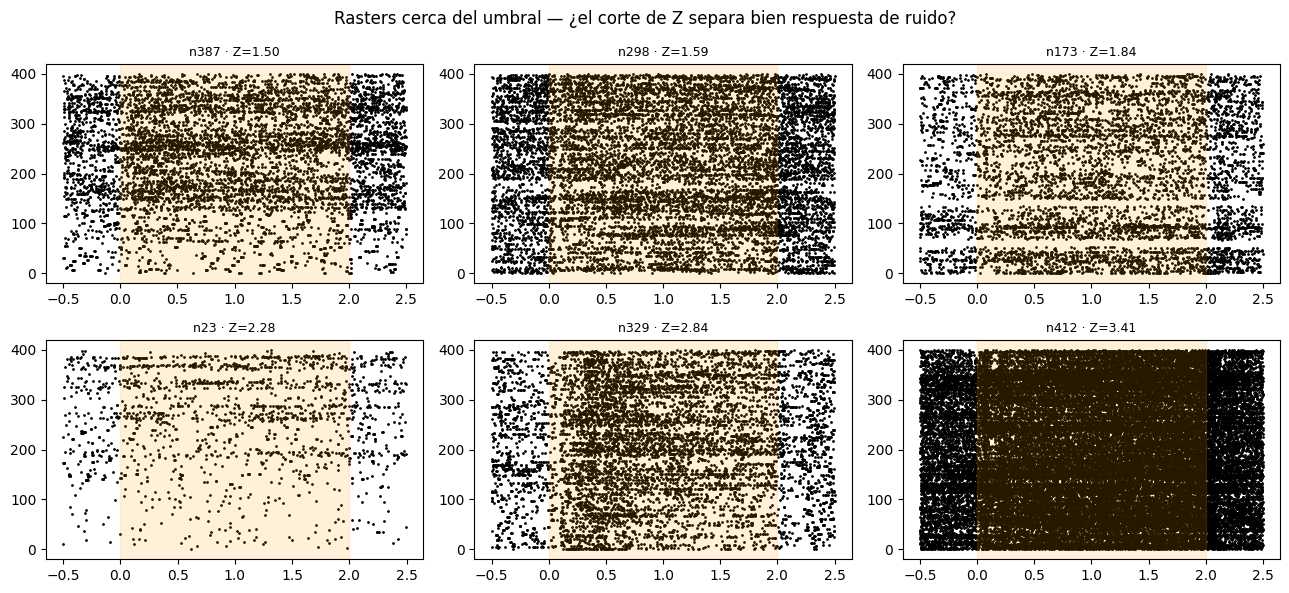

In [8]:
BIN_RASTER = 0.05  # tamaño de bin (s) para rasters y PSTH de neuronas individuales
bins_raster = np.arange(-0.5, 2.5 + BIN_RASTER, BIN_RASTER)
centros_raster = bins_raster[:-1] + BIN_RASTER / 2

cand = neurona.dropna(subset=['z_drift']).copy()
cerca = cand[(cand['z_drift'] > 1.5) & (cand['z_drift'] < 3.5)].sort_values('z_drift')

n_muestra = min(6, len(cerca))
muestra = cerca.iloc[np.linspace(0, len(cerca) - 1, n_muestra).astype(int)]

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, (idx, row) in zip(axes.flat, muestra.iterrows()):
    raton = row['u_raton']
    ens = idx_drifting[ensayos.loc[idx_drifting, 'e_raton'].values == raton]
    spk_n = spikes[spikes['s_unidad'] == idx]
    for fila, e in enumerate(ens):
        t = spk_n.loc[spk_n['s_ensayo'] == e, 's_t']
        t = t[(t >= -0.5) & (t <= 2.5)]
        ax.scatter(t, np.full(len(t), fila), s=1, color='k')
    ax.axvspan(0, DUR_DRIFT, color='orange', alpha=0.15)
    ax.set_title(f"n{idx} · Z={row['z_drift']:.2f}", fontsize=9)

for ax in axes.flat[n_muestra:]:
    ax.axis('off')

plt.suptitle('Rasters cerca del umbral — ¿el corte de Z separa bien respuesta de ruido?')
plt.tight_layout()
plt.show()


**Decisión de umbral:** revisando los rasters de arriba, un Z de 2.5 separa razonablemente bien las
neuronas que muestran un aumento visible de espigas dentro de la ventana de estímulo (sombreada en naranja) de
las que no. Fijamos este valor y lo usamos consistentemente en el resto del notebook.

In [9]:
UMBRAL = 2.5  # justificado visualmente arriba; se documenta también en la sección de métodos del póster


## 9. Fracción de neuronas respondedoras a movimiento (global y por ratón)

Este es el número que compartimos con las otras 10 parejas el día de la presentación (nota al pie de la
sección 6 del enunciado): la fracción de neuronas de nuestra área que responde a rejillas en movimiento.

In [10]:
respondedoras = (neurona['z_drift'] >= UMBRAL).sum()
fraccion = respondedoras / n_neuronas
print(f"Neuronas respondedoras a movimiento: {respondedoras} de {n_neuronas} ({fraccion*100:.1f}%)")

print(f"\n{'Ratón':>12}  {'n neuronas':>10}  {'fracción':>10}")
fracciones_por_raton = {}
for raton in neurona['u_raton'].unique():
    mask = neurona['u_raton'] == raton
    n_r = mask.sum()
    resp_r = (neurona.loc[mask, 'z_drift'] >= UMBRAL).sum()
    frac_r = resp_r / n_r
    fracciones_por_raton[raton] = frac_r
    print(f"{raton:>12}  {n_r:>10}  {frac_r*100:>9.1f}%")


Neuronas respondedoras a movimiento: 42 de 431 (9.7%)

       Ratón  n neuronas    fracción
   750749662         145        3.4%
   715093703         147       17.7%
   798911424          66        9.1%
   761418226          43        4.7%
   756029989          30       10.0%


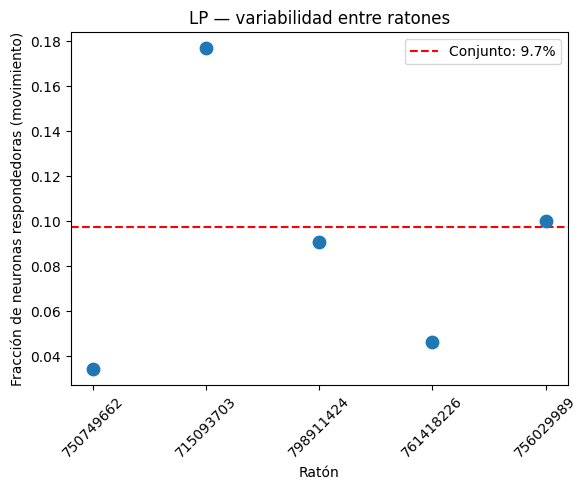

In [11]:
# --- Gráfica: fracción respondedora por ratón, contra el valor del conjunto completo ---
ratones_ord = list(fracciones_por_raton.keys())
fracciones_vals = [fracciones_por_raton[r] for r in ratones_ord]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(range(len(ratones_ord)), fracciones_vals, s=80, zorder=3)
ax.axhline(fraccion, color='red', linestyle='--', label=f'Conjunto: {fraccion*100:.1f}%')
ax.set_xticks(range(len(ratones_ord)))
ax.set_xticklabels([str(r) for r in ratones_ord], rotation=45)
ax.set_xlabel('Ratón')
ax.set_ylabel('Fracción de neuronas respondedoras (movimiento)')
ax.set_title(f'{MI_AREA} — variabilidad entre ratones')
ax.legend()
plt.tight_layout()
plt.show()


## 10. Figura 1, Panel C — forma de onda promedio de la neurona ejemplo

Elegimos como neurona ejemplo la de mayor Z-score a movimiento (la misma que usamos en el Panel D, para que
el póster sea consistente). `u_onda` ya viene promediada de fábrica: es la forma de onda en microvoltios, en
los 7 canales alrededor del de mayor amplitud — lo mismo que se midió a mano en el Taller 2.

In [12]:
idx_ejemplo = neurona['z_drift'].idxmax()
raton_ejemplo = neurona.loc[idx_ejemplo, 'u_raton']
print(f"Neurona ejemplo: {idx_ejemplo}, ratón {raton_ejemplo}, "
      f"Z_drift = {neurona.loc[idx_ejemplo, 'z_drift']:.2f}")


Neurona ejemplo: 45, ratón 750749662, Z_drift = 21.00


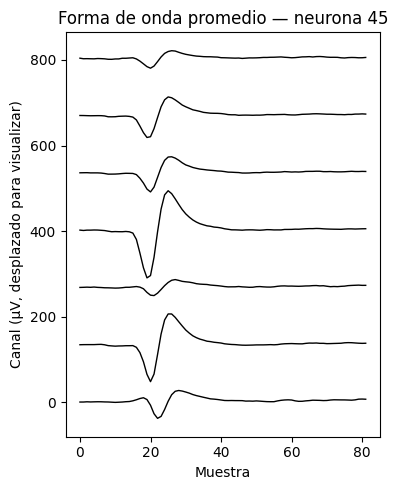

In [13]:
onda = np.asarray(neurona.loc[idx_ejemplo, 'u_onda'])  # forma (7 canales, n_muestras)

# Salvaguarda de orientación, por si el arreglo viniera transpuesto
if onda.shape[0] != 7 and onda.ndim == 2 and onda.shape[1] == 7:
    onda = onda.T

fig, ax = plt.subplots(figsize=(4, 5))
offset = np.nanmax(np.abs(onda)) * 1.2  # separa visualmente los 7 canales
for c in range(onda.shape[0]):
    ax.plot(onda[c] + c * offset, color='k', lw=1)

ax.set_title(f'Forma de onda promedio — neurona {idx_ejemplo}')
ax.set_xlabel('Muestra')
ax.set_ylabel('Canal (µV, desplazado para visualizar)')
plt.tight_layout()
plt.savefig('fig1C_onda.png', dpi=150)
plt.show()


## 11. Figura 1, Panel D — raster y PSTH de la neurona ejemplo

Espigas alineadas al inicio del ensayo (raster, arriba) y su promedio sobre ensayos (PSTH, abajo), con banda
de error estándar (SEM) — requisito explícito de la sección 6 del enunciado ("Importante: las líneas de PSTH
tienen que tener sombreado de error estándar").

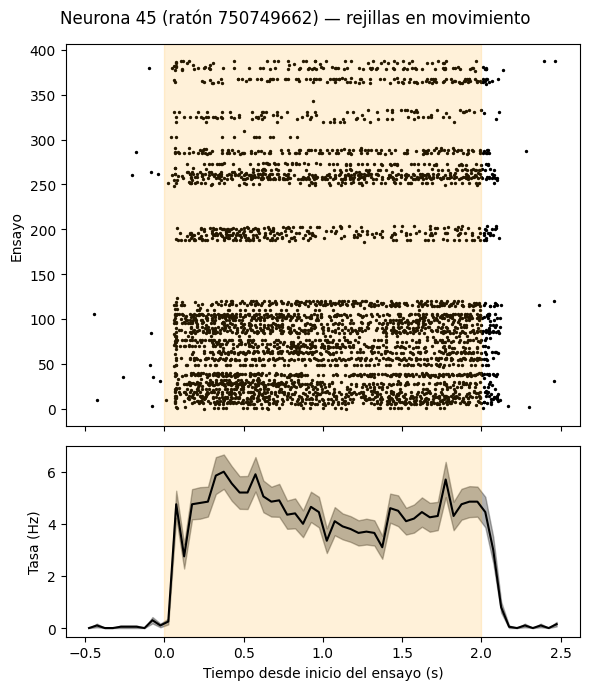

In [14]:
ens_ejemplo = idx_drifting[ensayos.loc[idx_drifting, 'e_raton'].values == raton_ejemplo]
spk_ejemplo = spikes[spikes['s_unidad'] == idx_ejemplo]

tasas_ejemplo = []
fig, (axr, axp) = plt.subplots(2, 1, figsize=(6, 7), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})
for fila, e in enumerate(ens_ejemplo):
    t = spk_ejemplo.loc[spk_ejemplo['s_ensayo'] == e, 's_t']
    t = t[(t >= -0.5) & (t <= 2.5)]
    axr.scatter(t, np.full(len(t), fila), s=2, color='k')
    conteo, _ = np.histogram(t, bins=bins_raster)
    tasas_ejemplo.append(conteo / BIN_RASTER)

tasas_ejemplo = np.array(tasas_ejemplo)
psth_ejemplo = tasas_ejemplo.mean(axis=0)
sem_ejemplo  = tasas_ejemplo.std(axis=0) / np.sqrt(tasas_ejemplo.shape[0])

axr.axvspan(0, DUR_DRIFT, color='orange', alpha=0.15)
axr.set_ylabel('Ensayo')

axp.plot(centros_raster, psth_ejemplo, color='k')
axp.fill_between(centros_raster, psth_ejemplo - sem_ejemplo, psth_ejemplo + sem_ejemplo,
                  color='k', alpha=0.3)  # banda de SEM
axp.axvspan(0, DUR_DRIFT, color='orange', alpha=0.15)
axp.set_xlabel('Tiempo desde inicio del ensayo (s)')
axp.set_ylabel('Tasa (Hz)')

plt.suptitle(f'Neurona {idx_ejemplo} (ratón {raton_ejemplo}) — rejillas en movimiento')
plt.tight_layout()
plt.savefig('fig1D_raster_psth.png', dpi=150)
plt.show()


## 12. Diagnóstico adicional (no es una figura del póster): raster y PSTH por ratón

Este panel no es obligatorio, pero ayuda a confirmar visualmente que cada ratón, individualmente, muestra el
mismo patrón de respuesta (y a detectar si alguno se comporta de forma atípica). Usamos la neurona con mayor
Z de movimiento **dentro de cada ratón**.

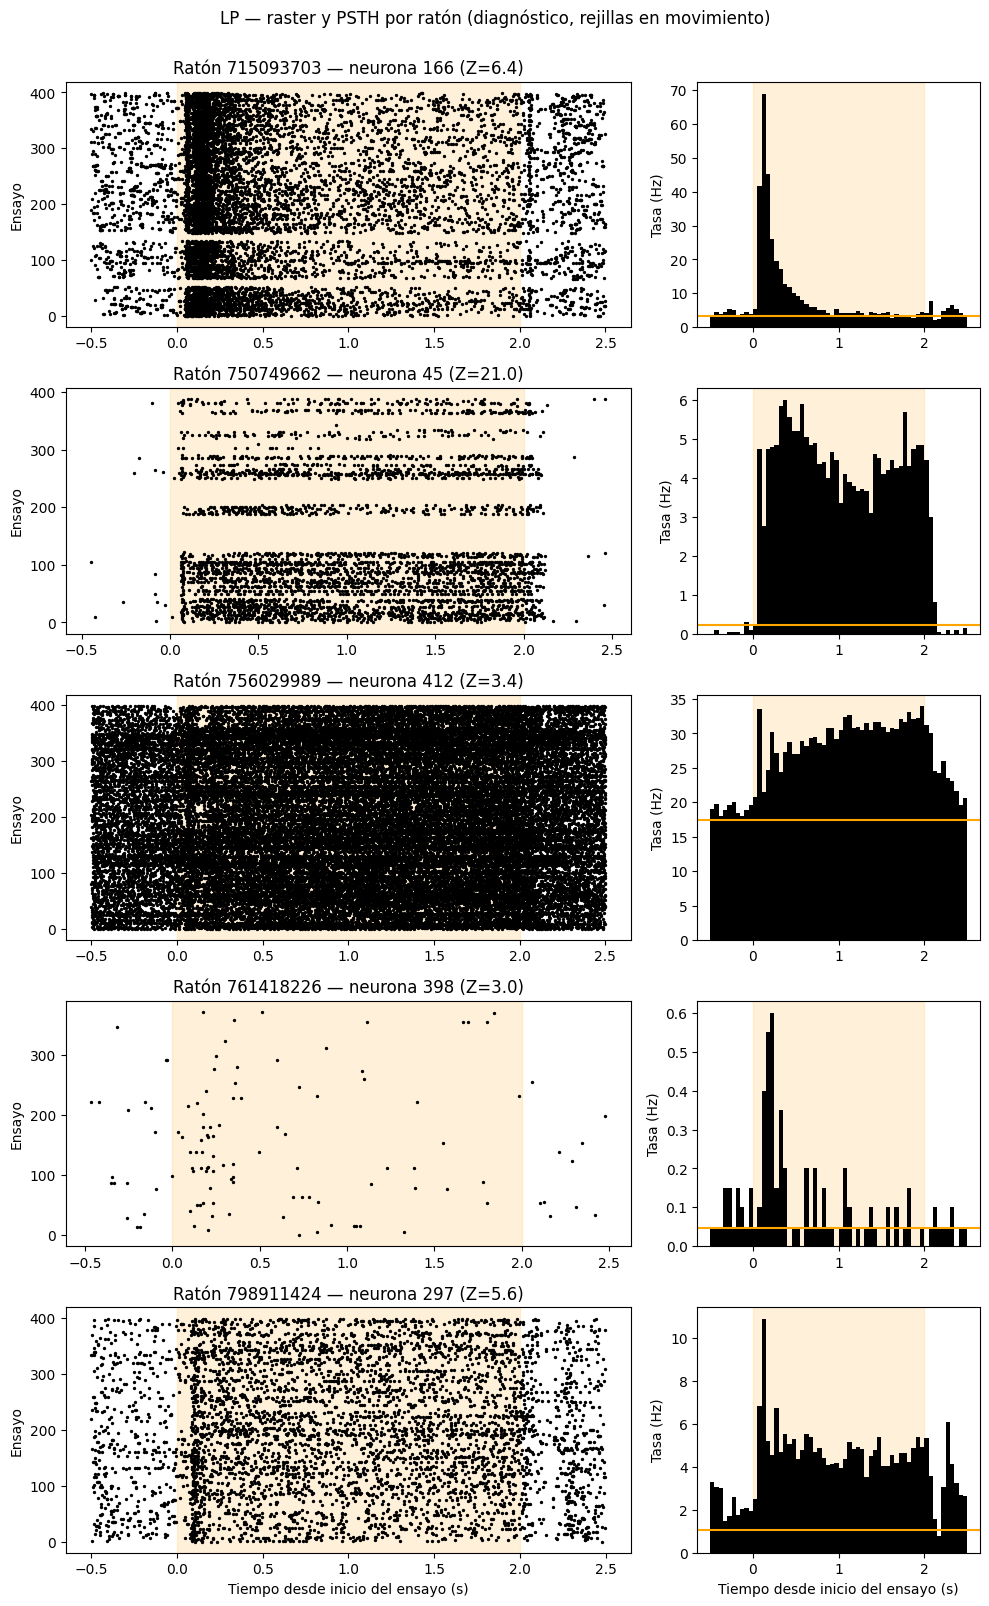

In [15]:
ratones_todos = sorted(neurona['u_raton'].unique())

fig, axes = plt.subplots(len(ratones_todos), 2, figsize=(10, 3.2 * len(ratones_todos)),
                          gridspec_kw={'width_ratios': [2, 1]})

for fila_ax, raton in enumerate(ratones_todos):
    mask_raton = neurona['u_raton'] == raton
    idx_r = neurona.loc[mask_raton, 'z_drift'].idxmax()
    z_r = neurona.loc[idx_r, 'z_drift']

    ens_r = idx_drifting[ensayos.loc[idx_drifting, 'e_raton'].values == raton]
    spk_r = spikes[spikes['s_unidad'] == idx_r]

    ax_r, ax_p = axes[fila_ax, 0], axes[fila_ax, 1]

    tasas_r = []
    for fila, e in enumerate(ens_r):
        t = spk_r.loc[spk_r['s_ensayo'] == e, 's_t']
        t = t[(t >= -0.5) & (t <= 2.5)]
        ax_r.scatter(t, np.full(len(t), fila), s=2, color='k')
        conteo, _ = np.histogram(t, bins=bins_raster)
        tasas_r.append(conteo / BIN_RASTER)

    ax_r.axvspan(0, DUR_DRIFT, color='orange', alpha=0.15, zorder=0)
    ax_r.set_ylabel('Ensayo')
    ax_r.set_title(f'Ratón {raton} — neurona {idx_r} (Z={z_r:.1f})')
    if fila_ax == len(ratones_todos) - 1:
        ax_r.set_xlabel('Tiempo desde inicio del ensayo (s)')

    psth_r = np.mean(tasas_r, axis=0)
    ax_p.bar(centros_raster, psth_r, width=BIN_RASTER, color='k')

    tasa_basal_r = tasa_basal.loc[idx_r].dropna().mean()
    ax_p.axvspan(0, DUR_DRIFT, color='orange', alpha=0.15, zorder=0)
    ax_p.axhline(tasa_basal_r, color='orange', ls='-', lw=1.5)
    ax_p.set_ylabel('Tasa (Hz)')
    if fila_ax == len(ratones_todos) - 1:
        ax_p.set_xlabel('Tiempo desde inicio del ensayo (s)')

plt.suptitle(f'{MI_AREA} — raster y PSTH por ratón (diagnóstico, rejillas en movimiento)', y=1.001)
plt.tight_layout()
plt.savefig('diagnostico_por_raton.png', dpi=150)
plt.show()


## 13. Función optimizada de PSTH poblacional

Calcular el PSTH de las 431 neuronas, para varias clases de estímulo, requiere filtrar la tabla de espigas
(más de 10.8 millones de filas) una y otra vez. Filtrarla completa dentro de un ciclo por neurona es
extremadamente lento (cientos de escaneos completos de la tabla).

**Optimización:** agrupamos `spikes` por neurona **una sola vez** con `groupby`, y cada neurona consulta
directamente su propio subconjunto (unos pocos miles de filas) en vez de la tabla completa.

In [16]:
print("Agrupando spikes por neurona (una sola vez)...")
spikes_por_unidad = {u: df for u, df in spikes.groupby('s_unidad')}
print("Listo.")

BIN_POP = 0.02  # bin más fino para los PSTH poblacionales (muchas neuronas / ensayos, se puede afinar)

def matriz_psth_por_neurona(idx_ensayos, dur, pre=0.5, post=0.5, bs=BIN_POP):
    """Devuelve (centros, M) donde M es una matriz neurona x tiempo: el PSTH de cada
    neurona, promediado sobre SUS propios ensayos (los de su ratón)."""
    b = np.arange(-pre, dur + post + bs, bs)
    c = b[:-1] + bs / 2

    raton_ens = ensayos.loc[idx_ensayos, 'e_raton']
    M = np.full((n_neuronas, len(c)), np.nan)

    for n in range(n_neuronas):
        e_n = idx_ensayos[raton_ens.values == neurona.loc[n, 'u_raton']]
        if len(e_n) == 0:
            continue

        spk_n = spikes_por_unidad.get(n)
        if spk_n is None:
            continue
        spk_n = spk_n[spk_n['s_ensayo'].isin(e_n)]

        tasas = [np.histogram(spk_n.loc[spk_n['s_ensayo'] == e, 's_t'], bins=b)[0] / bs
                 for e in e_n]
        M[n] = np.mean(tasas, axis=0)

    return c, M


Agrupando spikes por neurona (una sola vez)...
Listo.


## 14. Figura 2, Panel A — PSTH poblacional a movimiento

Tasa de disparo promediada sobre ensayos y sobre las 431 neuronas, con SEM. En el título reportamos el
porcentaje de neuronas respondedoras — el "eje común" que se compara entre las 11 parejas el día de la
presentación.

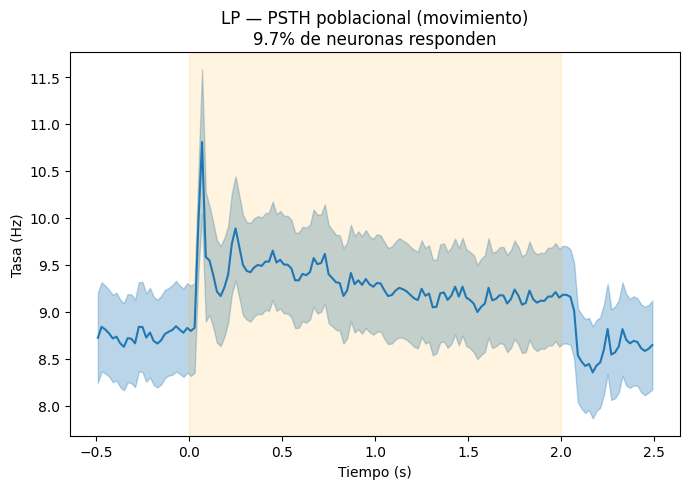

In [17]:
c_drift, M_drift = matriz_psth_por_neurona(idx_drifting, dur=DUR_DRIFT)
psth_pop_drift = np.nanmean(M_drift, axis=0)
sem_pop_drift  = np.nanstd(M_drift, axis=0) / np.sqrt(np.sum(~np.isnan(M_drift[:, 0])))

pct_resp = (neurona['z_drift'] >= UMBRAL).mean() * 100

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(c_drift, psth_pop_drift, color='tab:blue')
ax.fill_between(c_drift, psth_pop_drift - sem_pop_drift, psth_pop_drift + sem_pop_drift,
                 color='tab:blue', alpha=0.3)
ax.axvspan(0, DUR_DRIFT, color='orange', alpha=0.12)
ax.set_title(f'{MI_AREA} — PSTH poblacional (movimiento)\n{pct_resp:.1f}% de neuronas responden')
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Tasa (Hz)')
plt.tight_layout()
plt.savefig('fig2A.png', dpi=150)
plt.show()


## 15. Figura 2, Panel B — PSTH poblacional por clase de estímulo

Comparamos movimiento y estáticas, cada una con su propia ventana de tiempo (2 s vs. 250 ms), tal como exige
la sección 6 del enunciado: *"agrupar PSTHs de estímulos con la misma ventana de tiempo de estímulo"* — como
nuestras dos clases tienen duraciones distintas, cada una se grafica con su propia línea, sin combinarlas.

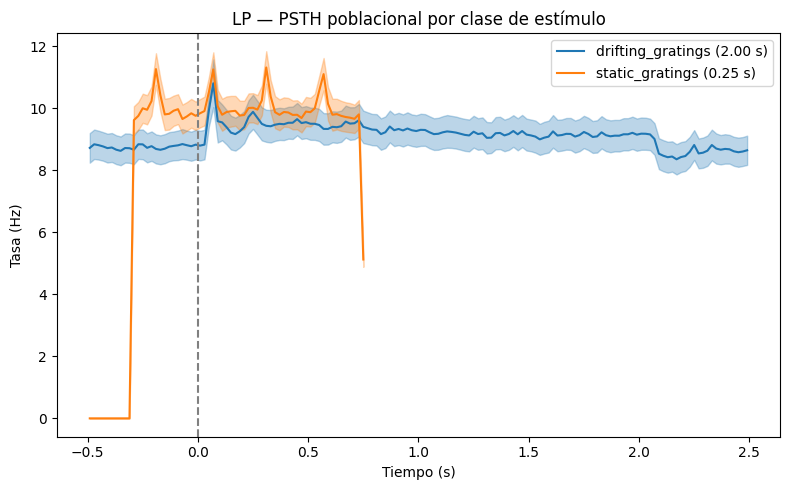

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))

for clase, idx_c, dur, color in [
    ('drifting_gratings', idx_drifting, DUR_DRIFT, 'tab:blue'),
    ('static_gratings',   idx_static,   DUR_STATIC, 'tab:orange'),
]:
    c, M = matriz_psth_por_neurona(idx_c, dur=dur)
    m = np.nanmean(M, axis=0)
    s = np.nanstd(M, axis=0) / np.sqrt(np.sum(~np.isnan(M[:, 0])))
    ax.plot(c, m, color=color, label=f'{clase} ({dur:.2f} s)')
    ax.fill_between(c, m - s, m + s, color=color, alpha=0.3)  # banda de SEM

ax.axvline(0, color='gray', ls='--')
ax.legend()
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Tasa (Hz)')
ax.set_title(f'{MI_AREA} — PSTH poblacional por clase de estímulo')
plt.tight_layout()
plt.savefig('fig2B.png', dpi=150)
plt.show()


## 16. Figura 2, Panel C — mapa de calor de Z-score por estímulo

Una fila por neurona, una columna por clase de estímulo. Cada celda es el Z-score de esa neurona contra su
propia basal (no la combinación preferida — aquí queremos comparar clases entre sí, así que usamos el
promedio simple de cada clase). Ordenamos las filas de mayor a menor Z de movimiento, para ver de un vistazo
si las neuronas más activas a movimiento también responden a otras clases.

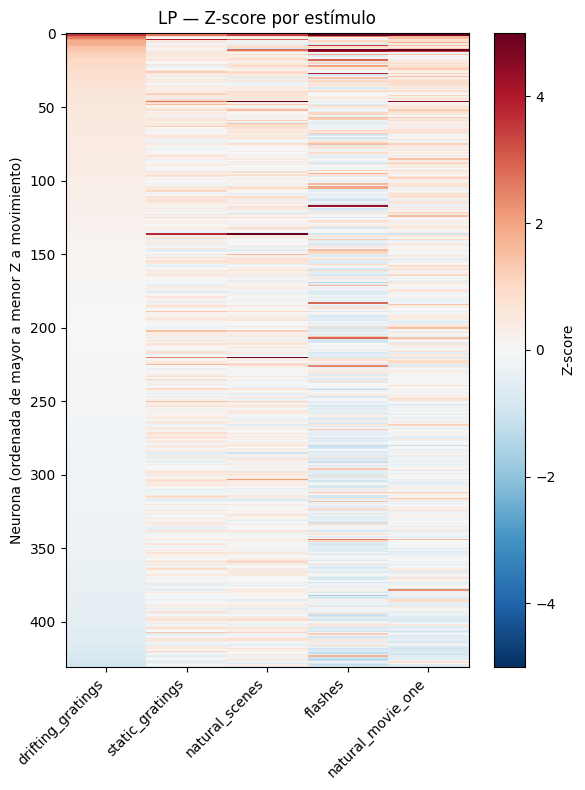

In [28]:
def z_por_clase(clase, dur):
    """Z-score simple (promedio de la clase completa, sin combinación preferida) de
    cada neurona para una clase de estímulo dada, contra su propia basal."""
    idx_c = np.where(ensayos['e_clase'] == clase)[0]
    te = calcular_tasas(idx_c, ventana=dur)
    z = np.full(n_neuronas, np.nan)
    for n in range(n_neuronas):
        ev = te.loc[n].dropna()
        bl = tasa_basal.loc[n].dropna()
        if len(ev) == 0 or bl.std() == 0 or np.isnan(bl.std()):
            continue
        z[n] = (ev.mean() - bl.mean()) / bl.std()
    return z

clases_heatmap = {
    'drifting_gratings': DUR_DRIFT,
    'static_gratings':   DUR_STATIC,
    'natural_scenes':    0.25,
    'flashes':           0.25,
    'natural_movie_one': 30.0,
}
Z_por_estimulo = pd.DataFrame({cl: z_por_clase(cl, d) for cl, d in clases_heatmap.items()})

# Orden explícito de mayor a menor Z de movimiento; los NaN (sin dato) quedan al final
orden = Z_por_estimulo['drifting_gratings'].sort_values(ascending=False, na_position='last').index

fig, ax = plt.subplots(figsize=(6, 8))
im = ax.imshow(Z_por_estimulo.loc[orden].values, aspect='auto', cmap='RdBu_r',
               vmin=-5, vmax=5, interpolation='nearest')
ax.set_xticks(range(len(Z_por_estimulo.columns)))
ax.set_xticklabels(Z_por_estimulo.columns, rotation=45, ha='right')
ax.set_ylabel('Neurona (ordenada de mayor a menor Z a movimiento)')
plt.colorbar(im, label='Z-score')
ax.set_title(f'{MI_AREA} — Z-score por estímulo')
plt.tight_layout()
plt.savefig('fig2C.png', dpi=150)
plt.show()


## 17. Figura 2, Panel D — enjambre de Z-score por condición asignada

Un punto por neurona: su Z-score (condición preferida) en movimiento y en estáticas — nuestra comparación
asignada. La línea roja marca el umbral fijado en la sección 8.

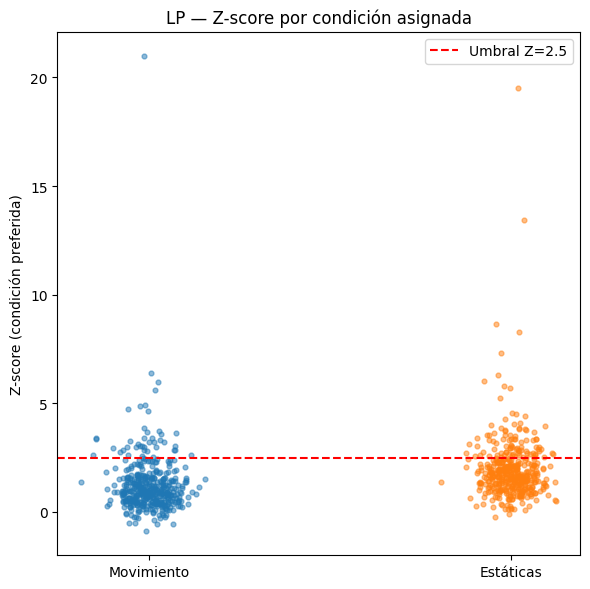

In [29]:
largo = pd.DataFrame({
    'Movimiento': neurona['z_drift'],
    'Estáticas':  neurona['z_static'],
}).melt(var_name='Condición', value_name='Z').dropna()

rng_jitter = np.random.default_rng(0)  # semilla fija para que el jitter sea reproducible

fig, ax = plt.subplots(figsize=(6, 6))
for i, cond in enumerate(['Movimiento', 'Estáticas']):
    vals = largo.loc[largo['Condición'] == cond, 'Z'].values
    x = rng_jitter.normal(i, 0.05, len(vals))
    ax.scatter(x, vals, s=12, alpha=0.5)

ax.axhline(UMBRAL, color='red', ls='--', label=f'Umbral Z={UMBRAL}')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Movimiento', 'Estáticas'])
ax.set_ylabel('Z-score (condición preferida)')
ax.legend()
ax.set_title(f'{MI_AREA} — Z-score por condición asignada')
plt.tight_layout()
plt.savefig('fig2D.png', dpi=150)
plt.show()


## 18. Bootstrap jerárquico de tres niveles — sección 7 del enunciado

Nuestras 431 neuronas no son observaciones independientes: las de un mismo ratón comparten ese animal.
Tratarlas como independientes daría un intervalo de confianza falsamente angosto.

⚠️ **Advertencia más importante del enunciado (sección 7):** *"si le piden el bootstrap al modelo de lenguaje
sin insistir en los tres niveles, es muy probable que les escriba uno que remuestrea la tabla plana de
neuronas. Corre, da números y está mal. Revisen que el sorteo de ratones esté ahí."* — En el código de abajo,
`ratones_boot = rng.choice(ratones_lista, ...)` es exactamente ese sorteo de ratones (nivel 1), y está
presente. Dentro de cada ratón remuestreado se sortean sus neuronas (nivel 2), y dentro de cada neurona, sus
ensayos (nivel 3), 10.000 réplicas en total.

In [30]:
rng = np.random.default_rng(0)

def tasas_condicion_preferida(idx_ensayos, carac_cols, dur):
    """Para cada neurona: sus tasas de disparo (uno por ensayo) en su combinación
    preferida de características, más su arreglo de tasas basales. Se precomputa una
    sola vez para no repetir este trabajo en cada una de las 10.000 réplicas."""
    te = calcular_tasas(idx_ensayos, ventana=dur)
    carac_local = ensayos.loc[idx_ensayos, ['e_raton'] + carac_cols].copy()
    carac_local['combo'] = list(zip(*[carac_local[c] for c in carac_cols]))

    pref, basal = {}, {}
    for n in range(n_neuronas):
        fila = te.loc[n].dropna()
        if len(fila) == 0:
            pref[n], basal[n] = np.array([]), np.array([])
            continue
        combos = carac_local.loc[fila.index, 'combo']
        validos = combos.apply(lambda c: not any(pd.isna(x) for x in c))
        fila, combos = fila[validos], combos[validos]
        if len(fila) == 0:
            pref[n], basal[n] = np.array([]), np.array([])
            continue
        combo_pref = fila.groupby(combos).mean().idxmax()
        pref[n] = fila.loc[combos[combos == combo_pref].index].values
        basal[n] = tasa_basal.loc[n].dropna().values
    return pref, basal


# --- Precómputo por neurona, para cada condición ---
pref_drift, basal_todas = tasas_condicion_preferida(
    idx_drifting, ['e_orientacion', 'e_frec_temporal', 'e_frec_espacial'], DUR_DRIFT)
pref_static, _ = tasas_condicion_preferida(
    idx_static, ['e_orientacion', 'e_frec_espacial'], DUR_STATIC)

# --- Mapa ratón -> índices de sus neuronas ---
neur_por_raton = {r: neurona.index[neurona['u_raton'] == r].values
                   for r in neurona['u_raton'].unique()}
ratones_lista = list(neur_por_raton.keys())


def z_de_una_replica(pref_vals, basal_vals, rng):
    """Z-score de una neurona, remuestreando sus ensayos con reemplazo (nivel 3)."""
    if len(pref_vals) == 0 or len(basal_vals) == 0:
        return np.nan
    ev = rng.choice(pref_vals, len(pref_vals), replace=True).mean()
    bl = rng.choice(basal_vals, len(basal_vals), replace=True)
    sd = bl.std()
    if sd == 0:
        return np.nan
    return (ev - bl.mean()) / sd


def fraccion_respondedora_bootstrap(pref, rng):
    """Una réplica completa del bootstrap jerárquico: sortea ratones (nivel 1),
    dentro de cada uno sortea neuronas (nivel 2), y calcula el Z de cada una
    remuestreando sus ensayos (nivel 3). Devuelve la fracción de neuronas
    (en esa réplica) con Z >= UMBRAL."""
    ratones_boot = rng.choice(ratones_lista, len(ratones_lista), replace=True)  # NIVEL 1: ratones
    z_replica = []
    for r in ratones_boot:
        neuronas_r = neur_por_raton[r]
        neuronas_boot = rng.choice(neuronas_r, len(neuronas_r), replace=True)   # NIVEL 2: neuronas
        for n in neuronas_boot:
            z_replica.append(z_de_una_replica(pref[n], basal_todas[n], rng))    # NIVEL 3: ensayos
    z_replica = np.array(z_replica)
    return np.nanmean(z_replica >= UMBRAL)


N_REPLICAS = 10000  # sección 7 del enunciado: 10.000 réplicas
boot_drift  = np.array([fraccion_respondedora_bootstrap(pref_drift,  rng) for _ in range(N_REPLICAS)])
boot_static = np.array([fraccion_respondedora_bootstrap(pref_static, rng) for _ in range(N_REPLICAS)])

ic_drift  = np.percentile(boot_drift,  [2.5, 97.5])
ic_static = np.percentile(boot_static, [2.5, 97.5])

print(f"Movimiento: fracción = {boot_drift.mean():.3f}  IC95%% = [{ic_drift[0]:.3f}, {ic_drift[1]:.3f}]"
      .replace("%%", "%"))
print(f"Estáticas:  fracción = {boot_static.mean():.3f}  IC95%% = [{ic_static[0]:.3f}, {ic_static[1]:.3f}]"
      .replace("%%", "%"))


Movimiento: fracción = 0.114  IC95% = [0.050, 0.188]
Estáticas:  fracción = 0.275  IC95% = [0.221, 0.327]


## 19. Prueba de permutación — valor p

Contrastamos si la fracción respondedora difiere entre movimiento y estáticas permutando, para cada neurona,
cuál de sus dos Z-scores (movimiento/estáticas) se etiqueta como cuál — respetando que es una comparación
pareada por neurona (cada neurona contribuye un Z a cada condición).

In [22]:
z_d = neurona['z_drift'].values
z_s = neurona['z_static'].values
mask_validas = ~(np.isnan(z_d) | np.isnan(z_s))
z_d, z_s = z_d[mask_validas], z_s[mask_validas]

diferencia_observada = (z_d >= UMBRAL).mean() - (z_s >= UMBRAL).mean()

N_PERM = 10000
permutaciones = np.empty(N_PERM)
pares = np.column_stack([z_d, z_s])
for i in range(N_PERM):
    flip = rng.random(len(pares)) < 0.5  # para cada neurona, ¿se intercambian sus dos etiquetas?
    a = np.where(flip, pares[:, 1], pares[:, 0])
    b = np.where(flip, pares[:, 0], pares[:, 1])
    permutaciones[i] = (a >= UMBRAL).mean() - (b >= UMBRAL).mean()

p_valor = (np.abs(permutaciones) >= np.abs(diferencia_observada)).mean()
print(f"Diferencia observada (movimiento - estáticas): {diferencia_observada:.3f}")
print(f"Valor p (permutación, {N_PERM} permutaciones): {p_valor:.4f}")


Diferencia observada (movimiento - estáticas): -0.121
Valor p (permutación, 10000 permutaciones): 0.0000


## 20. Tamaño del efecto — d de Cohen

Definido en la sección 6 del enunciado: la diferencia entre las dos condiciones dividida por su desviación
estándar, calculada sobre la diferencia pareada por neurona (Z de movimiento menos Z de estáticas).

In [23]:
diferencia_pareada = z_d - z_s
d_cohen = diferencia_pareada.mean() / diferencia_pareada.std(ddof=1)
print(f"d de Cohen: {d_cohen:.2f}")


d de Cohen: -0.43


## 21. La "trampa": bootstrap jerárquico vs. t-test ingenuo

El enunciado pide comparar nuestro intervalo de confianza jerárquico contra el de un t-test que trata cada
neurona como una observación independiente, ignorando el ratón — y reportar la diferencia como un resultado
en sí mismo (sección 7 del enunciado).

In [24]:
from scipy import stats

frac_obs_drift = (z_d >= UMBRAL).mean()
n_validas = len(z_d)
se_ingenuo = np.sqrt(frac_obs_drift * (1 - frac_obs_drift) / n_validas)
ic_ingenuo = frac_obs_drift + np.array([-1, 1]) * 1.96 * se_ingenuo

print(f"IC ingenuo (normal, ignora el ratón):  [{ic_ingenuo[0]:.3f}, {ic_ingenuo[1]:.3f}]  "
      f"ancho = {np.diff(ic_ingenuo)[0]:.3f}")
print(f"IC bootstrap jerárquico (3 niveles):    [{ic_drift[0]:.3f}, {ic_drift[1]:.3f}]  "
      f"ancho = {np.diff(ic_drift)[0]:.3f}")
print(f"\nEl intervalo jerárquico es {np.diff(ic_drift)[0] / np.diff(ic_ingenuo)[0]:.1f}x más ancho: "
      f"ignorar la agrupación por ratón habría dado una precisión falsa.")


IC ingenuo (normal, ignora el ratón):  [0.069, 0.125]  ancho = 0.056
IC bootstrap jerárquico (3 niveles):    [0.050, 0.188]  ancho = 0.138

El intervalo jerárquico es 2.5x más ancho: ignorar la agrupación por ratón habría dado una precisión falsa.


## 22. Figura 2, Panel E — fracción respondedora con IC, p y d de Cohen

El panel que resume la comparación asignada: fracción de neuronas respondedoras en cada condición, con
intervalo de confianza del bootstrap jerárquico, el valor p de la permutación y la d de Cohen.

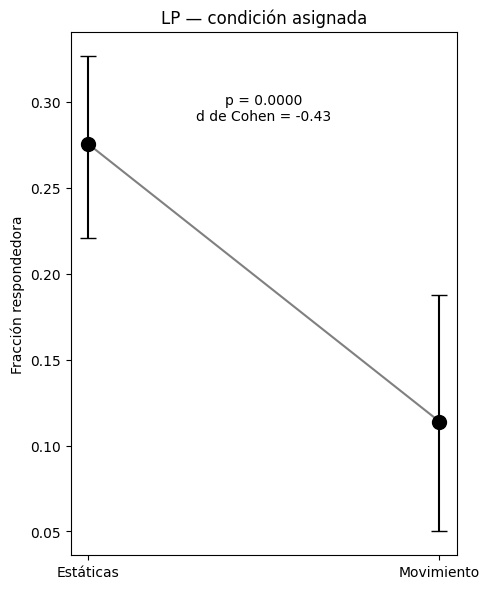

In [25]:
fig, ax = plt.subplots(figsize=(5, 6))
xs = [0, 1]
medias = [boot_static.mean(), boot_drift.mean()]
ics = [ic_static, ic_drift]

for x, m, ic in zip(xs, medias, ics):
    ax.errorbar(x, m, yerr=[[m - ic[0]], [ic[1] - m]], fmt='o', ms=10, capsize=6, color='k')
ax.plot(xs, medias, '-', color='gray')

ax.set_xticks(xs)
ax.set_xticklabels(['Estáticas', 'Movimiento'])
ax.set_ylabel('Fracción respondedora')
ax.set_title(f'{MI_AREA} — condición asignada')
ax.text(0.5, max(medias) * 1.05, f'p = {p_valor:.4f}\nd de Cohen = {d_cohen:.2f}', ha='center')

plt.tight_layout()
plt.savefig('fig2E.png', dpi=150)
plt.show()


## 23. Resumen final de resultados

Todos los números que van en la sección de métodos y resultados del póster, en un solo lugar.

In [26]:
print("="*70)
print(f"RESUMEN DE RESULTADOS — Área {MI_AREA}")
print("="*70)
print(f"Neuronas analizadas: {n_neuronas}  ·  Ratones: {len(ratones_lista)}")
print(f"Umbral de respuesta: Z >= {UMBRAL} (validado visualmente con rasters, sección 8)")
print()
print(f"Fracción respondedora a MOVIMIENTO:  {boot_drift.mean()*100:.1f}%  "
      f"(IC95% [{ic_drift[0]*100:.1f}%, {ic_drift[1]*100:.1f}%])")
print(f"Fracción respondedora a ESTÁTICAS:   {boot_static.mean()*100:.1f}%  "
      f"(IC95% [{ic_static[0]*100:.1f}%, {ic_static[1]*100:.1f}%])")
print()
print(f"Prueba de permutación: diferencia = {diferencia_observada:.3f}, p = {p_valor:.4f}")
print(f"Tamaño del efecto: d de Cohen = {d_cohen:.2f}")
print()
print(f"IC ingenuo (sin jerarquía): ancho = {np.diff(ic_ingenuo)[0]:.3f}")
print(f"IC jerárquico (3 niveles):  ancho = {np.diff(ic_drift)[0]:.3f}")
print()
print("Referencia de los datos:")
print("Siegle JH et al. (2021). Survey of spiking in the mouse visual system")
print("reveals functional hierarchy. Nature 592, 86-92.")
print("="*70)


RESUMEN DE RESULTADOS — Área LP
Neuronas analizadas: 431  ·  Ratones: 5
Umbral de respuesta: Z >= 2.5 (validado visualmente con rasters, sección 8)

Fracción respondedora a MOVIMIENTO:  11.4%  (IC95% [5.0%, 18.8%])
Fracción respondedora a ESTÁTICAS:   27.5%  (IC95% [22.1%, 32.7%])

Prueba de permutación: diferencia = -0.121, p = 0.0000
Tamaño del efecto: d de Cohen = -0.43

IC ingenuo (sin jerarquía): ancho = 0.056
IC jerárquico (3 niveles):  ancho = 0.138

Referencia de los datos:
Siegle JH et al. (2021). Survey of spiking in the mouse visual system
reveals functional hierarchy. Nature 592, 86-92.
